In [2]:
import pandas as pd
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Dataset Loading

In this section, the insurance dataset is loaded into a Pandas DataFrame.
The dataset will be used for exploratory data analysis, preprocessing,
feature engineering, and regression model development.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

## 2. Importing Libraries

The required Python libraries are imported for data loading, data
analysis, visualization, preprocessing, and regression model development.

In [5]:
# Display dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1338
Number of columns: 7


In [6]:
# Display column names
df.columns.tolist()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [7]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
# Display descriptive statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## 3. Missing Value Analysis

Missing values are checked for every column in the dataset. Identifying
missing values is important because incomplete data can affect the
performance of machine learning models.

In [10]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1


## 4. Duplicate Record Analysis

The dataset is checked for duplicate rows. Duplicate observations may
affect the analysis and model training, so they need to be identified
before preprocessing.

In [11]:
# ============================================================
# 5. REMOVE DUPLICATES
# ============================================================

print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows before removal: 1
Duplicate rows after removal: 0
New dataset shape: (1337, 7)


In [12]:
# ============================================================
#  CHECK MISSING VALUES AFTER CLEANING
# ============================================================

print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [13]:
# ============================================================
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['age', 'bmi', 'children', 'charges']

Categorical columns:
['sex', 'smoker', 'region']


In [14]:
# ============================================================
# UNIQUE VALUES OF CATEGORICAL FEATURES
# ============================================================

print("Sex:", df["sex"].unique())
print("Smoker:", df["smoker"].unique())
print("Region:", df["region"].unique())

Sex: <StringArray>
['female', 'male']
Length: 2, dtype: str
Smoker: <StringArray>
['yes', 'no']
Length: 2, dtype: str
Region: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


## EDA

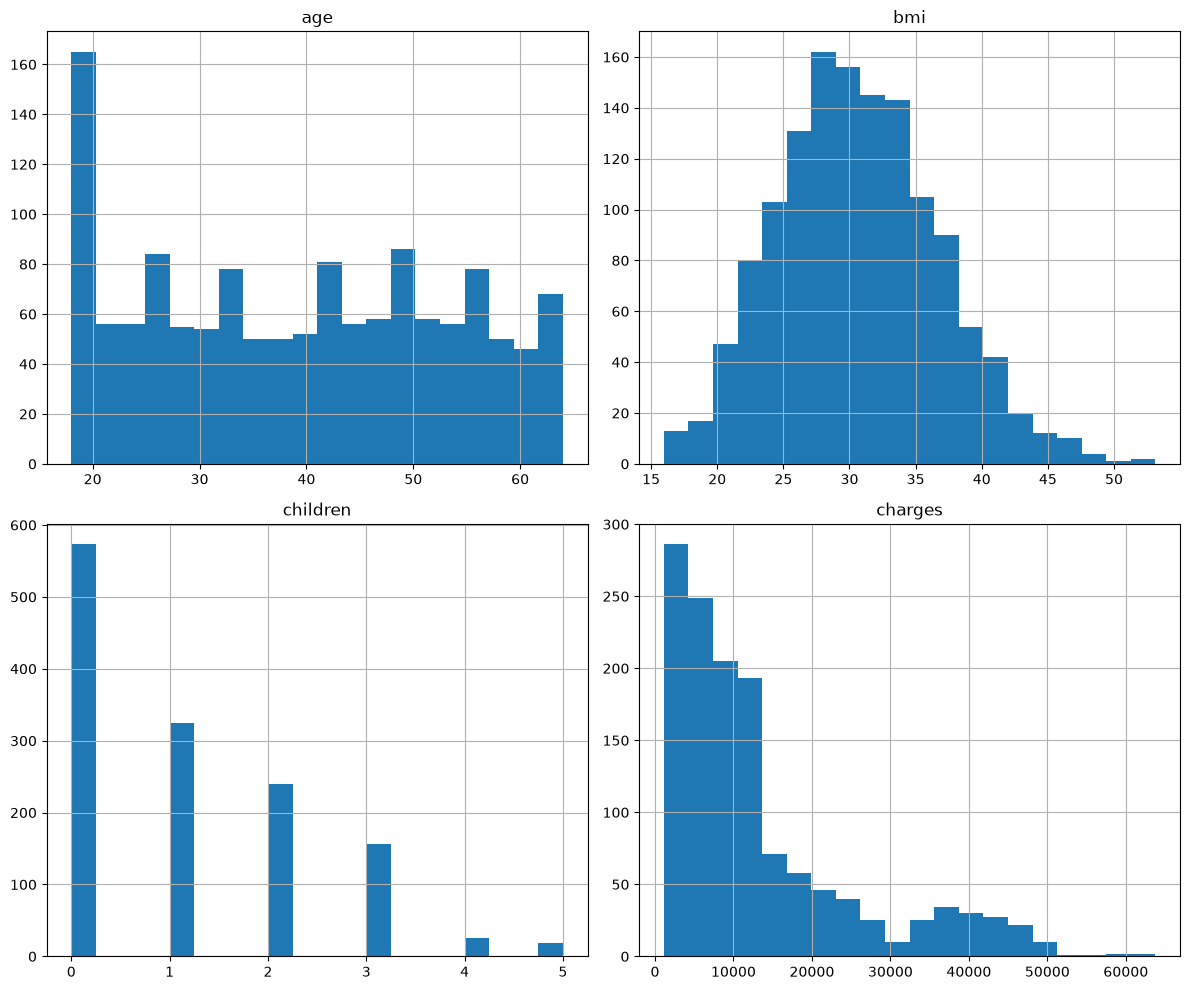

In [15]:
# ============================================================
# DISTRIBUTION OF NUMERICAL FEATURES
# ============================================================

df[["age", "bmi", "children", "charges"]].hist(
    figsize=(12, 10),
    bins=20
)

plt.tight_layout()
plt.show()

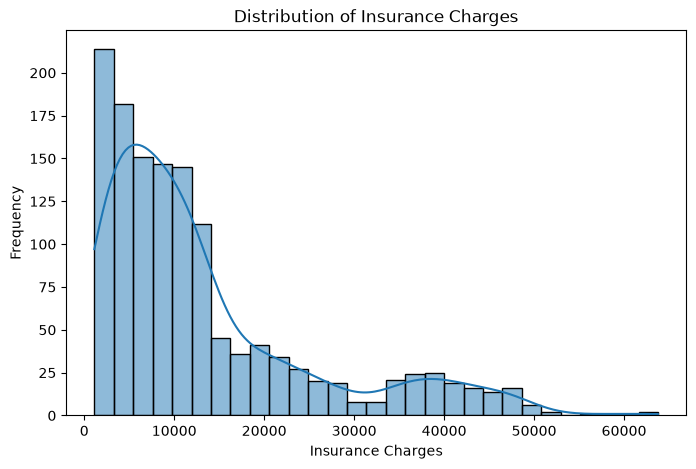

In [16]:
# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.show()

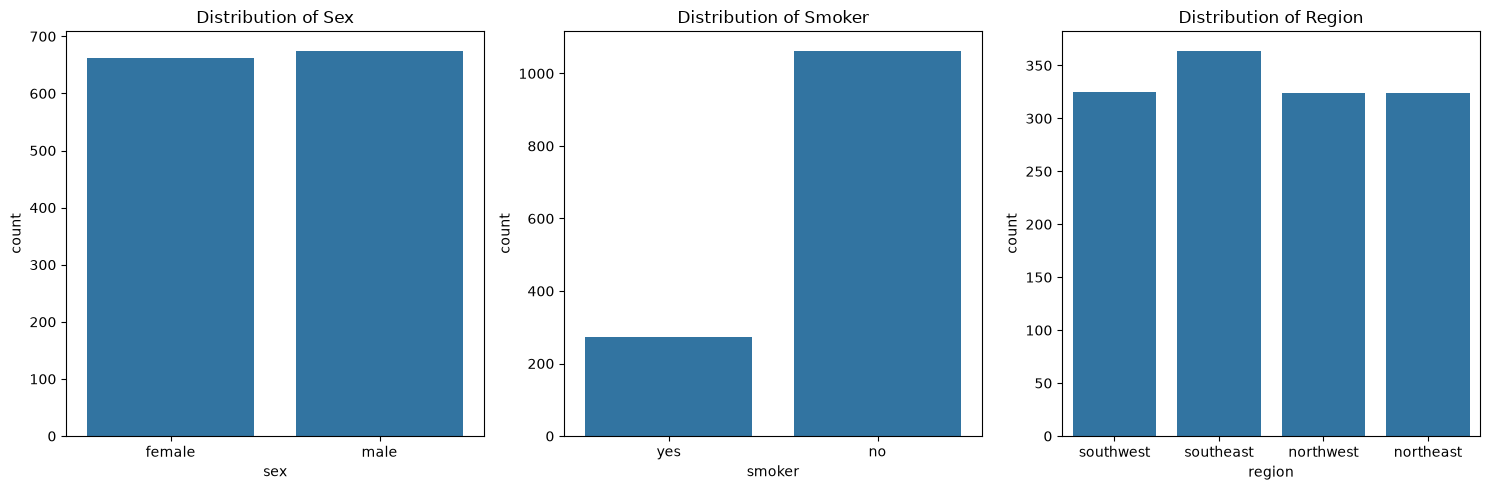

In [17]:
# ============================================================
# CATEGORICAL FEATURE DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(data=df, x="sex", ax=axes[0])
axes[0].set_title("Distribution of Sex")

sns.countplot(data=df, x="smoker", ax=axes[1])
axes[1].set_title("Distribution of Smoker")

sns.countplot(data=df, x="region", ax=axes[2])
axes[2].set_title("Distribution of Region")

plt.tight_layout()
plt.show()

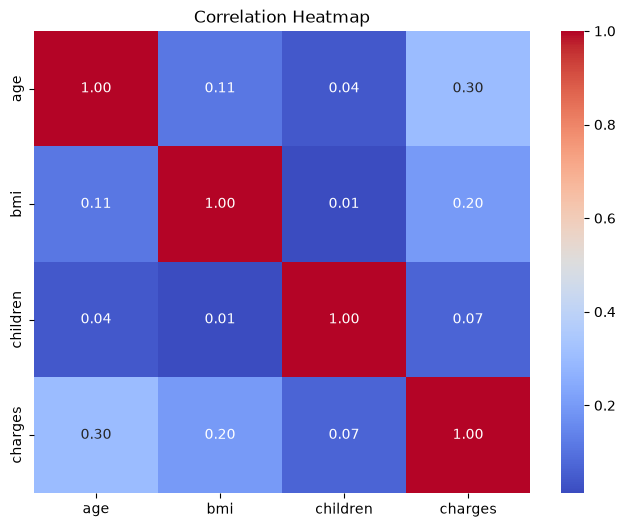

In [18]:
# ============================================================
#  CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

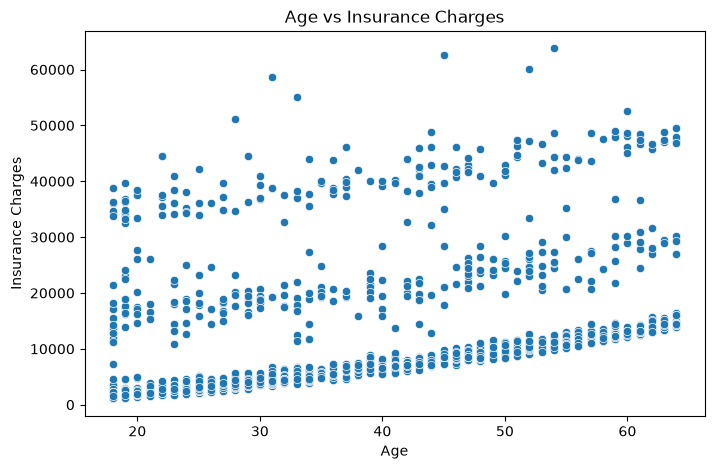

In [19]:
# ============================================================
# AGE VS CHARGES
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges"
)

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

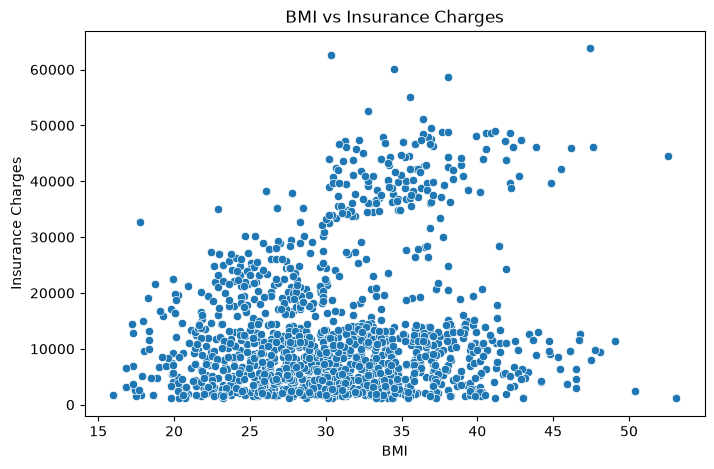

In [20]:
# ============================================================
#  BMI VS CHARGES
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

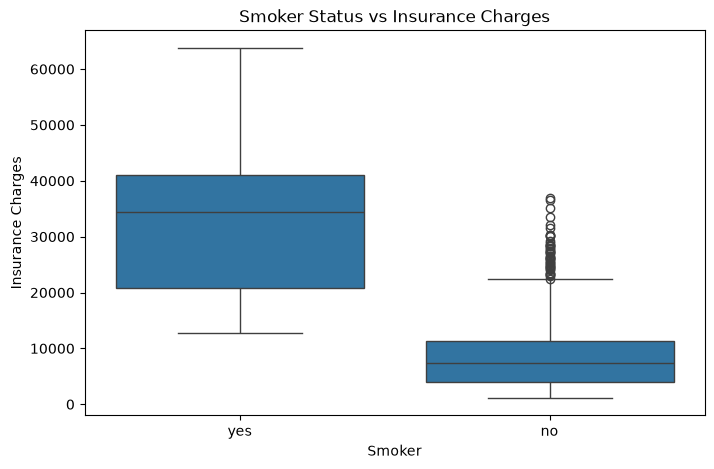

In [21]:
# ============================================================
# SMOKER VS CHARGES
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Smoker Status vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")

plt.show()

## OUTLIER CHECKING

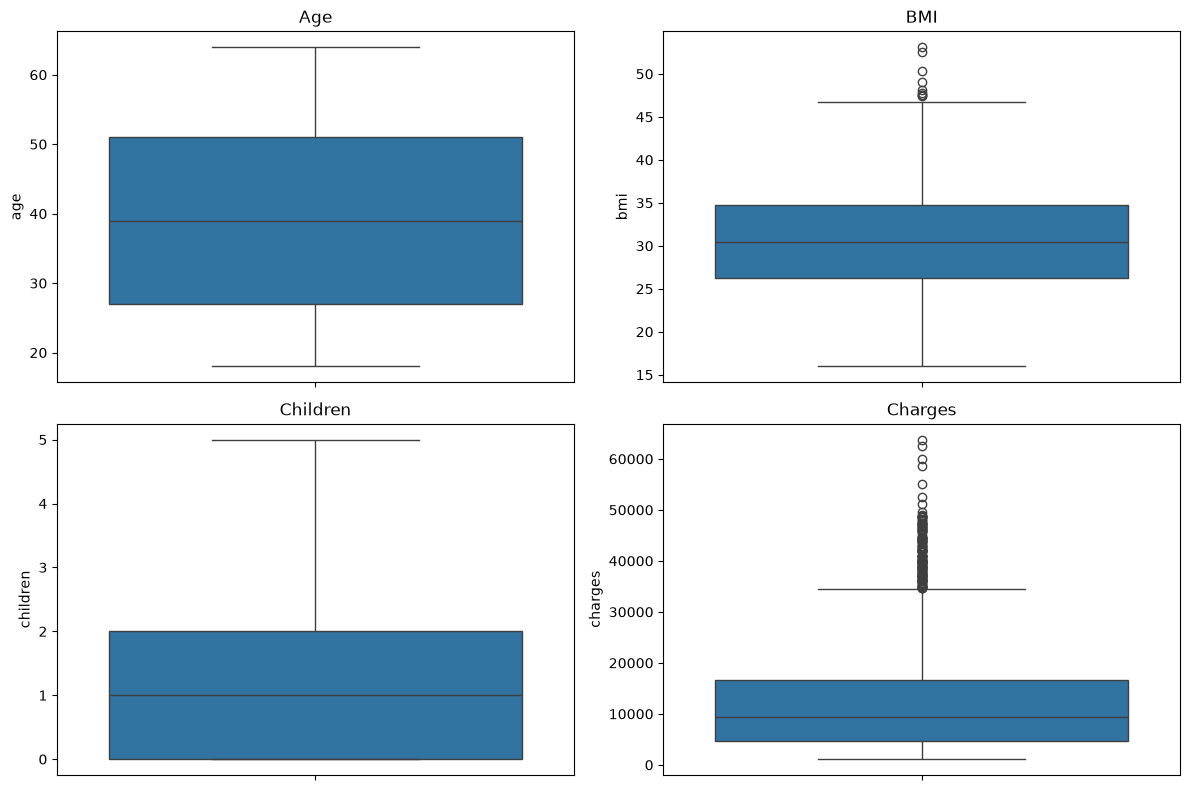

In [22]:
# ============================================================
# 19. BOX PLOTS FOR OUTLIER DETECTION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(y=df["age"], ax=axes[0, 0])
axes[0, 0].set_title("Age")

sns.boxplot(y=df["bmi"], ax=axes[0, 1])
axes[0, 1].set_title("BMI")

sns.boxplot(y=df["children"], ax=axes[1, 0])
axes[1, 0].set_title("Children")

sns.boxplot(y=df["charges"], ax=axes[1, 1])
axes[1, 1].set_title("Charges")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# COUNT OUTLIERS USING IQR
# ============================================================

for column in ["age", "bmi", "children"]:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(column, ":", len(outliers), "outliers")

age : 0 outliers
bmi : 9 outliers
children : 0 outliers


In [24]:
# IQR Capping for Numerical Input Features

numeric_features = ["age", "bmi", "children"]

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("IQR capping completed successfully.")

# Check the new ranges
print("\nRanges after IQR capping:")
print(df[numeric_features].agg(["min", "max"]))

IQR capping completed successfully.

Ranges after IQR capping:
     age     bmi  children
min   18  15.960         0
max   64  47.315         5


In [25]:
# ============================================================
# 20. COUNT OUTLIERS USING IQR
# ============================================================

for column in ["age", "bmi", "children", "charges"]:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(column, ":", len(outliers), "outliers")

age : 0 outliers
bmi : 0 outliers
children : 0 outliers
charges : 139 outliers


In [26]:
# ============================================================
#  FEATURE ENGINEERING
# ============================================================

# Create BMI-age interaction feature
df["bmi_age"] = df["bmi"] * df["age"]

df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_age
0,19,female,27.900,0,yes,southwest,16884.92400,530.100
1,18,male,33.770,1,no,southeast,1725.55230,607.860
2,28,male,33.000,3,no,southeast,4449.46200,924.000
3,33,male,22.705,0,no,northwest,21984.47061,749.265
4,32,male,28.880,0,no,northwest,3866.85520,924.160


In [27]:
# ============================================================
# SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("charges", axis=1)
y = df["charges"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("charges")

Features:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'bmi_age']

Target:
charges


In [28]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1069, 7)
Testing set: (268, 7)


In [29]:
# ============================================================
#  ONE-HOT ENCODING
# ============================================================

X_train_encoded = pd.get_dummies(
    X_train,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

# Make sure both datasets have the same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (1069, 9)
Encoded testing shape: (268, 9)


In [30]:
# ============================================================
#  STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Training data standardized.")
print("Testing data standardized.")

Training data standardized.
Testing data standardized.


## Linear Regression

In this step, I am using Linear Regression to predict the medical insurance charges based on the given input features.

Linear Regression is a basic regression algorithm that tries to find the relationship between the input variables and the target variable. After training the model with the training data, I use it to predict the insurance charges for the test data.

To check how well the model performs, I use three evaluation metrics: R² score, RMSE, and MAE. A higher R² score indicates better performance, while lower RMSE and MAE values indicate that the predictions are closer to the actual insurance charges.

The same test data will be used for the other regression algorithms so that their performance can be compared fairly.

In [31]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_linear = linear_model.predict(X_test_scaled)

# Calculate evaluation metrics
linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

# Display results
print("Linear Regression Results")
print("-------------------------")
print("R² Score :", linear_r2)
print("RMSE     :", linear_rmse)
print("MAE      :", linear_mae)

Linear Regression Results
-------------------------
R² Score : 0.8070379156399762
RMSE     : 5954.658103633202
MAE      : 4181.439120967571


## Ridge Regression

Ridge Regression uses L2 regularisation to reduce the effect of large coefficients. The alpha parameter controls the strength of the regularisation.

In [36]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_age
0,19,female,27.900,0,yes,southwest,16884.92400,530.100
1,18,male,33.770,1,no,southeast,1725.55230,607.860
2,28,male,33.000,3,no,southeast,4449.46200,924.000
3,33,male,22.705,0,no,northwest,21984.47061,749.265
4,32,male,28.880,0,no,northwest,3866.85520,924.160


## Ridge Regression

Ridge Regression is a linear regression technique that uses L2 regularization to reduce the effect of large coefficients.

In this project, Ridge Regression is used to predict medical insurance charges. The `alpha` parameter controls the strength of regularization.

In [32]:
# Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Create the Ridge model
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate evaluation metrics
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

# Display results
print("Ridge Regression Results")
print("------------------------")
print("R² Score :", ridge_r2)
print("RMSE     :", ridge_rmse)
print("MAE      :", ridge_mae)

Ridge Regression Results
------------------------
R² Score : 0.8068816657998079
RMSE     : 5957.068489349515
MAE      : 4184.533195441973


### Ridge Hyperparameter Tuning

Different values of `alpha` are tested using GridSearchCV with 5-fold cross-validation.

The best value of `alpha` is selected based on the R² score.

In [33]:
# Ridge Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Values of alpha to test
ridge_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Create GridSearchCV
ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring="r2"
)

# Train GridSearchCV
ridge_grid.fit(X_train_scaled, y_train)

# Display best parameter
print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(ridge_grid.best_score_)

Best Ridge Parameters:
{'alpha': 10}

Best Cross-Validation R²:
0.7254326316200421


### Tuned Ridge Regression Results

The Ridge model is retrained using the best `alpha` value found during hyperparameter tuning. Its performance is then evaluated using R², RMSE, and MAE.

In [34]:
# Evaluate Tuned Ridge Regression

# Get the best Ridge model
best_ridge = ridge_grid.best_estimator_

# Predict using the tuned model
y_pred_ridge_tuned = best_ridge.predict(X_test_scaled)

# Calculate evaluation metrics
ridge_tuned_r2 = r2_score(y_test, y_pred_ridge_tuned)
ridge_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_tuned))
ridge_tuned_mae = mean_absolute_error(y_test, y_pred_ridge_tuned)

# Display results
print("Tuned Ridge Regression Results")
print("------------------------------")
print("Best Alpha :", ridge_grid.best_params_["alpha"])
print("R² Score   :", ridge_tuned_r2)
print("RMSE       :", ridge_tuned_rmse)
print("MAE        :", ridge_tuned_mae)

print("\nR² Improvement:")
print(ridge_tuned_r2 - ridge_r2)

Tuned Ridge Regression Results
------------------------------
Best Alpha : 10
R² Score   : 0.8053063334817501
RMSE       : 5981.316063637163
MAE        : 4211.309260738659

R² Improvement:
-0.0015753323180578427


## Lasso Regression

Lasso Regression is a linear regression technique that uses L1 regularization.

It helps reduce the effect of less important features by shrinking some coefficients towards zero. In this project, Lasso Regression is used to predict medical insurance charges.

In [35]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Create the Lasso model
lasso_model = Lasso(alpha=0.1, max_iter=10000)

# Train the model
lasso_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate evaluation metrics
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

# Display results
print("Lasso Regression Results")
print("------------------------")
print("R² Score :", lasso_r2)
print("RMSE     :", lasso_rmse)
print("MAE      :", lasso_mae)

Lasso Regression Results
------------------------
R² Score : 0.8070362268890139
RMSE     : 5954.684160339197
MAE      : 4181.468829793182


## ElasticNet Regression

ElasticNet Regression combines both L1 and L2 regularization.

The `alpha` parameter controls the overall regularization strength, while `l1_ratio` controls the balance between L1 and L2 regularization. In this project, ElasticNet is used to predict medical insurance charges.

In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Create the ElasticNet model
elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000
)

# Train the model
elastic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_elastic = elastic_model.predict(X_test_scaled)

# Calculate evaluation metrics
elastic_r2 = r2_score(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)

# Display results
print("ElasticNet Regression Results")
print("-----------------------------")
print("R² Score :", elastic_r2)
print("RMSE     :", elastic_rmse)
print("MAE      :", elastic_mae)

ElasticNet Regression Results
-----------------------------
R² Score : 0.7969484187070918
RMSE     : 6108.351608716229
MAE      : 4337.254186306166


### ElasticNet Hyperparameter Tuning

Different combinations of `alpha` and `l1_ratio` are tested using GridSearchCV with 5-fold cross-validation.

The combination that gives the best R² score is selected as the final ElasticNet model.

In [37]:
from sklearn.model_selection import GridSearchCV

# Define parameters to test
elastic_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Create GridSearchCV
elastic_grid = GridSearchCV(
    ElasticNet(max_iter=10000),
    elastic_params,
    cv=5,
    scoring="r2"
)

# Perform hyperparameter tuning
elastic_grid.fit(X_train_scaled, y_train)

# Display the best parameters
print("Best ElasticNet Parameters:")
print(elastic_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(elastic_grid.best_score_)

Best ElasticNet Parameters:
{'alpha': 0.1, 'l1_ratio': 0.9}

Best Cross-Validation R²:
0.72541721432666


In [38]:
# Get the best ElasticNet model
best_elastic = elastic_grid.best_estimator_

# Make predictions
y_pred_elastic_tuned = best_elastic.predict(X_test_scaled)

# Calculate metrics
elastic_tuned_r2 = r2_score(y_test, y_pred_elastic_tuned)
elastic_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic_tuned))
elastic_tuned_mae = mean_absolute_error(y_test, y_pred_elastic_tuned)

# Display results
print("Tuned ElasticNet Regression Results")
print("------------------------------------")
print("Best Alpha    :", elastic_grid.best_params_["alpha"])
print("Best L1 Ratio :", elastic_grid.best_params_["l1_ratio"])
print("R² Score      :", elastic_tuned_r2)
print("RMSE          :", elastic_tuned_rmse)
print("MAE           :", elastic_tuned_mae)

print("\nR² Improvement:")
print(elastic_tuned_r2 - elastic_r2)

Tuned ElasticNet Regression Results
------------------------------------
Best Alpha    : 0.1
Best L1 Ratio : 0.9
R² Score      : 0.805178347178559
RMSE          : 5983.281717623662
MAE           : 4213.3428597328375

R² Improvement:
0.008229928471467196
